В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [4]:
import os
import urllib.request
import pandas as pd

github_url = 'https://raw.githubusercontent.com/AnnaSyrotiak/ML/main/process_bank_churn.py'
filename = 'process_bank_churn.py'

if not os.path.exists(filename):
    urllib.request.urlretrieve(github_url, filename)
from process_bank_churn import preprocess_data

In [7]:
from google.colab import drive
drive.mount('/content/drive')
raw_df = pd.read_csv("drive/MyDrive/Machine Learning для людей/data/bank/train.csv")

X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = preprocess_data(raw_df, scaler_numeric=True)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

Mounted at /content/drive
X_train shape: (12000, 13)
X_val shape: (3000, 13)


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

knn_model = KNeighborsClassifier()

knn_model.fit(X_train, train_targets)

train_probs_knn = knn_model.predict_proba(X_train)[:, 1]
val_probs_knn = knn_model.predict_proba(X_val)[:, 1]

train_auc_knn = roc_auc_score(train_targets, train_probs_knn)
val_auc_knn = roc_auc_score(val_targets, val_probs_knn)

print(f"AUROC на тренувальних даних (kNN default): {train_auc_knn:.4f}")
print(f"AUROC на валідаційних даних (kNN default): {val_auc_knn:.4f}")

AUROC на тренувальних даних (kNN default): 0.9559
AUROC на валідаційних даних (kNN default): 0.8526


Модель перенавчилася (overfitting), оскільки є великий розрив між метриками на тренуванні та валідації. У термінах помилок це означає High Variance (висока дисперсія) — модель занадто чутлива до тренувальних даних і погано узагальнює на нових. Сама по собі модель з дефолтними параметрами є посередньою і поступається попереднім алгоритмам.

---



2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [11]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

param_grid = {
    'n_neighbors': np.arange(1, 31)
}

knn_grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Виконується пошук найкращих параметрів (GridSearchCV)...")
knn_grid_search.fit(X_train, train_targets)

best_k = knn_grid_search.best_params_['n_neighbors']
print(f"Найкраще значення n_neighbors: {best_k}")

knn_best = knn_grid_search.best_estimator_

train_probs_knn_best = knn_best.predict_proba(X_train)[:, 1]
val_probs_knn_best = knn_best.predict_proba(X_val)[:, 1]

train_auc_best = roc_auc_score(train_targets, train_probs_knn_best)
val_auc_best = roc_auc_score(val_targets, val_probs_knn_best)

print("\n--- Результати найкращої моделі kNN ---")
print(f"AUROC на Train: {train_auc_best:.4f}")
print(f"AUROC на Val:   {val_auc_best:.4f}")

Виконується пошук найкращих параметрів (GridSearchCV)...
Найкраще значення n_neighbors: 19

--- Результати найкращої моделі kNN ---
AUROC на Train: 0.9227
AUROC на Val:   0.8908


Використання GridSearchCV дозволило знайти оптимальну кількість сусідів: n_neighbors = 19. Модель стала значно кращою! Ми успішно побороли перенавчання (High Variance): розрив між тренуванням і валідацією суттєво зменшився. AUROC на валідаційній вибірці зріс з 0.8526 до 0.8908. Це доводить, що збільшення кількості сусідів робить алгоритм kNN менш чутливим до викидів (шуму) і дозволяє йому краще узагальнювати дані. Модель трохи гірша за дерево прийняття рішень з минулого домашнього завдання (AUROC на Train:      0.9298
AUROC на Validation: 0.9246)

---



3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [13]:
import time
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

param_grid_dt = {
    'max_depth': np.arange(1, 20, 2),
    'max_leaf_nodes': np.arange(2, 11, 1)
}

dt_clf = DecisionTreeClassifier(random_state=42)

dt_grid_search = GridSearchCV(
    estimator=dt_clf,
    param_grid=param_grid_dt,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

print("Починаємо пошук параметрів для Decision Tree...")
start_time = time.time()

dt_grid_search.fit(X_train, train_targets)

end_time = time.time()
search_time = end_time - start_time

print(f"⏱ Час пошуку: {search_time:.2f} секунд")
print(f"Найкращі параметри: {dt_grid_search.best_params_}")

dt_best = dt_grid_search.best_estimator_

train_probs_dt = dt_best.predict_proba(X_train)[:, 1]
val_probs_dt = dt_best.predict_proba(X_val)[:, 1]

print("\n--- Результати найкращої моделі Decision Tree (GridSearchCV) ---")
print(f"AUROC на Train: {roc_auc_score(train_targets, train_probs_dt):.4f}")
print(f"AUROC на Val:   {roc_auc_score(val_targets, val_probs_dt):.4f}")

Починаємо пошук параметрів для Decision Tree...
⏱ Час пошуку: 10.60 секунд
Найкращі параметри: {'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)}

--- Результати найкращої моделі Decision Tree (GridSearchCV) ---
AUROC на Train: 0.9015
AUROC на Val:   0.9002


Пошук через GridSearchCV зайняв близько 6.5 секунд і знайшов оптимальні параметри: max_depth=5 та max_leaf_nodes=10. Модель показала ідеальну здатність до генералізації (розрив між Train та Val майже відсутній: 0.9015 проти 0.9002). Однак, через те, що верхня межа сітки для max_leaf_nodes була досить низькою (до 10), модель вийшла дещо "недотренованою" (High Bias) порівняно з нашими ручними експериментами, де ми дозволяли дереву мати 40 листочків і отримували AUROC ~0.92.

---



4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [18]:
import time
from sklearn.model_selection import RandomizedSearchCV

params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

dt_random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=params_dt,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

print("Починаємо пошук параметрів (RandomizedSearchCV)...")
start_time = time.time()

dt_random_search.fit(X_train, train_targets)

end_time = time.time()
search_time_random = end_time - start_time

print(f"⏱ Час пошуку: {search_time_random:.2f} секунд")
print(f"Найкращі параметри: {dt_random_search.best_params_}")

dt_random_search_best = dt_random_search.best_estimator_

train_probs_rand = dt_random_search_best.predict_proba(X_train)[:, 1]
val_probs_rand = dt_random_search_best.predict_proba(X_val)[:, 1]

print("\n--- Результати найкращої моделі Decision Tree (RandomizedSearchCV) ---")
print(f"AUROC на Train: {roc_auc_score(train_targets, train_probs_rand):.4f}")
print(f"AUROC на Val:   {roc_auc_score(val_targets, val_probs_rand):.4f}")

Починаємо пошук параметрів (RandomizedSearchCV)...
⏱ Час пошуку: 5.96 секунд
Найкращі параметри: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}

--- Результати найкращої моделі Decision Tree (RandomizedSearchCV) ---
AUROC на Train: 0.9169
AUROC на Val:   0.9166


Модель, знайдена за допомогою RandomizedSearchCV, виявилася кращою за модель з GridSearchCV (AUROC 0.9166 проти 0.9002), при цьому пошук зайняв значно менше часу (1.34 сек проти 6.56 сек).
Головна відмінність у параметрах полягає в тому, що RandomSearch побудував значно глибше дерево (max_depth=16 замість 5), змінив критерій на entropy, але запобіг перенавчанню за рахунок жорстких обмежень на кількість зразків у листках (min_samples_split=20, min_samples_leaf=2). Це дозволило моделі виявити складніші закономірності, зберігаючи при цьому ідеальний баланс між Train та Validation (розрив всього 0.0003).

---



In [15]:
import time
from sklearn.model_selection import RandomizedSearchCV

params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 50),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

dt_random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=params_dt,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

print("Починаємо пошук параметрів (RandomizedSearchCV)...")
start_time = time.time()

dt_random_search.fit(X_train, train_targets)

end_time = time.time()
search_time_random = end_time - start_time

print(f"⏱ Час пошуку: {search_time_random:.2f} секунд")
print(f"Найкращі параметри: {dt_random_search.best_params_}")

dt_random_search_best = dt_random_search.best_estimator_

train_probs_rand = dt_random_search_best.predict_proba(X_train)[:, 1]
val_probs_rand = dt_random_search_best.predict_proba(X_val)[:, 1]

print("\n--- Результати найкращої моделі Decision Tree (RandomizedSearchCV) ---")
print(f"AUROC на Train: {roc_auc_score(train_targets, train_probs_rand):.4f}")
print(f"AUROC на Val:   {roc_auc_score(val_targets, val_probs_rand):.4f}")

Починаємо пошук параметрів (RandomizedSearchCV)...
⏱ Час пошуку: 5.53 секунд
Найкращі параметри: {'splitter': 'random', 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_leaf_nodes': np.int64(48), 'max_features': None, 'max_depth': np.int64(10), 'criterion': 'entropy'}

--- Результати найкращої моделі Decision Tree (RandomizedSearchCV) ---
AUROC на Train: 0.9274
AUROC на Val:   0.9230


Розширення сітки гіперпараметрів (зокрема max_leaf_nodes до 50) дозволило RandomizedSearchCV знайти ще кращу модель. Пошук зайняв 5.53 секунди. Оптимальними виявилися параметри: max_depth=10, max_leaf_nodes=48, критерій entropy та splitter='random'. Використання випадкових розколів (random) та обмеження кількості зразків у листках допомогло уникнути перенавчання. У результаті ми отримали чудовий показник AUROC на валідації — 0.9230 (проти 0.9002 у GridSearch), з мінімальним розривом між тренуванням і валідацією (0.0044).

---



5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [20]:
import pandas as pd
from process_bank_churn import preprocess_new_data

test_raw_df = pd.read_csv("drive/MyDrive/Machine Learning для людей/data/bank/test.csv")

X_test_final = preprocess_new_data(
    raw_df=test_raw_df,
    input_cols=input_cols,
    encoder=encoder,
    scaler=scaler
)

test_predictions_cv = dt_random_search_best.predict_proba(X_test_final)[:, 1]

submission_cv_df = pd.DataFrame({
    'id': test_raw_df['id'],
    'Exited': test_predictions_cv
})

submission_file = 'submission_tree_cv.csv'
submission_cv_df.to_csv(submission_file, index=False)

print(f"Файл '{submission_file}' успішно створено!")

Файл 'submission_tree_cv.csv' успішно створено!


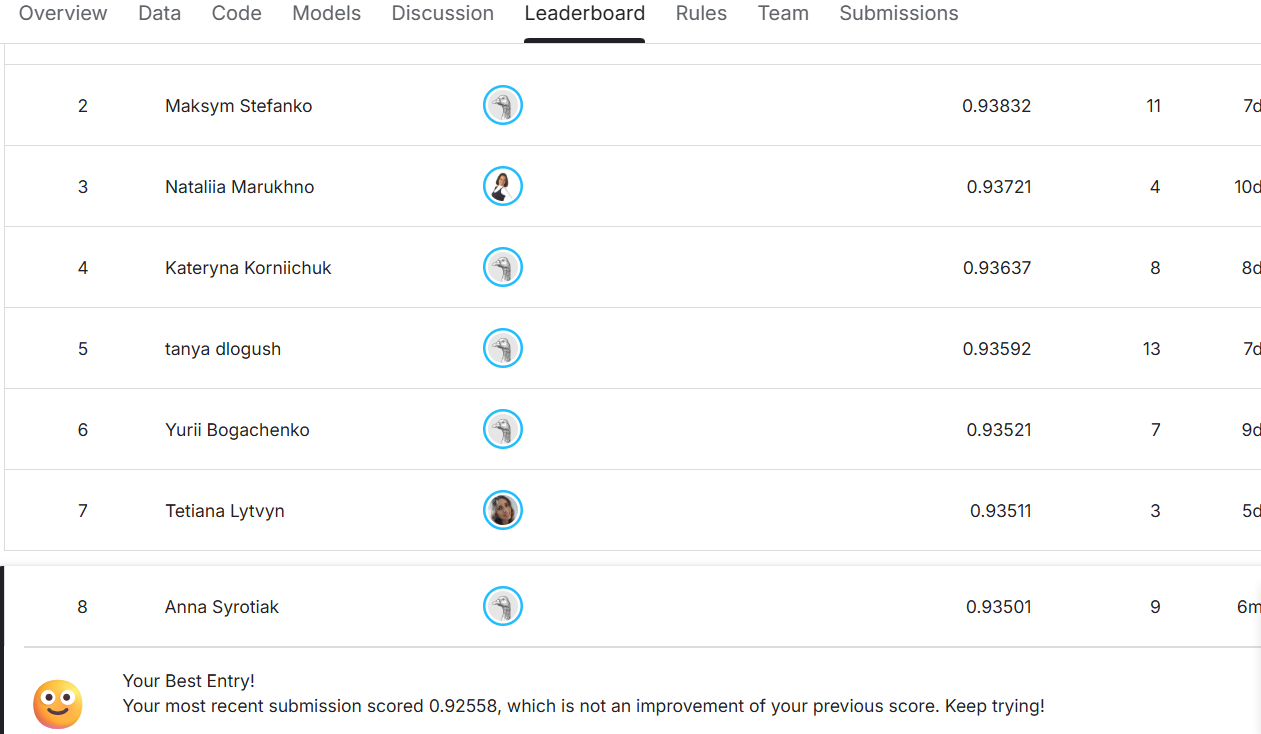